In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm  # tqdm是显示循环进度条的库
import time as time

class CliffWalkingEnv:
    def __init__(self, ncol, nrow):
        self.nrow = nrow
        self.ncol = ncol
        self.y = self.nrow -1
        self.x = 0
    
    def step(self, action):# next position, reward, done
        change = [[0,-1], [0, 1], [-1, 0], [1, 0]]
        self.x = min(self.ncol - 1, max(0, self.x + change[action][0]))
        self.y = min(self.nrow - 1, max(0, self.y + change[action][1]))
        reward = -1
        done = False
        next_state = self.y * self.ncol + self.x
        if self.y == self.nrow -1 and self.x > 0:
            done = True
            if self.x < self.ncol - 1:
                reward = -100
        return next_state, reward, done
    
    def reset(self):
        self.y = self.nrow -1
        self.x = 0
        return self.y * self.ncol + self.x          



# Qlearning
## init 
    input: self, ncol, nrow, epsilon, alpha, gamma, n_action = 4

## take action 
    input: state
    output: action

## update
    input: s0, a0, r, s1

Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 6940.08it/s, episode=500, return=-61.700]


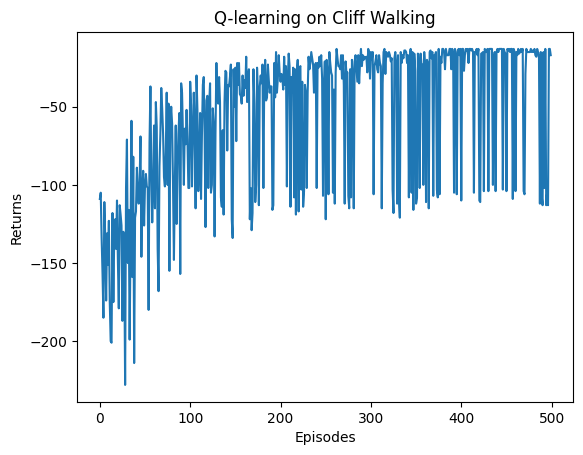

In [7]:
class QLearning:
    def __init__(self, ncol, nrow, epsilon, alpha, gamma, n_action=4):
        self.Q_table = np.zeros([nrow * ncol, n_action])
        self.n_action = n_action
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon


    def take_action(self, state):
        if np.random.rand() < self.epsilon:
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action
    
    def update(self, s0, a0, r, s1):
        td = r + self.gamma * self.Q_table[s1].max() - self.Q_table[s0, a0]
        self.Q_table[s0, a0] += self.alpha * td

np.random.seed(0)
ncol = 12
nrow = 4
env = CliffWalkingEnv(ncol, nrow)
epsilon = 0.1
alpha = 0.1
gamma = 0.9
agent = QLearning(ncol, nrow, epsilon, alpha, gamma)
num_episodes = 500  # 智能体在环境中运行的序列的数量

return_list = []  # 记录每一条序列的回报
for i in range(10):  # 显示10个进度条
    # tqdm的进度条功能
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):  # 每个进度条的序列数
            episode_return = 0
            state = env.reset()
            done = False
            while not done:
                action = agent.take_action(state)
                next_state, reward, done = env.step(action)
                episode_return += reward  # 这里回报的计算不进行折扣因子衰减
                agent.update(state, action, reward, next_state)
                state = next_state
            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:  # 每10条序列打印一下这10条序列的平均回报
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Q-learning on {}'.format('Cliff Walking'))
plt.show()

# action_meaning = ['^', 'v', '<', '>']
# print('Q-learning算法最终收敛得到的策略为：')
# print_agent(agent, env, action_meaning, list(range(37, 47)), [47])


# decreasing epsilon

Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 7993.72it/s, episode=500, return=-13.000] 


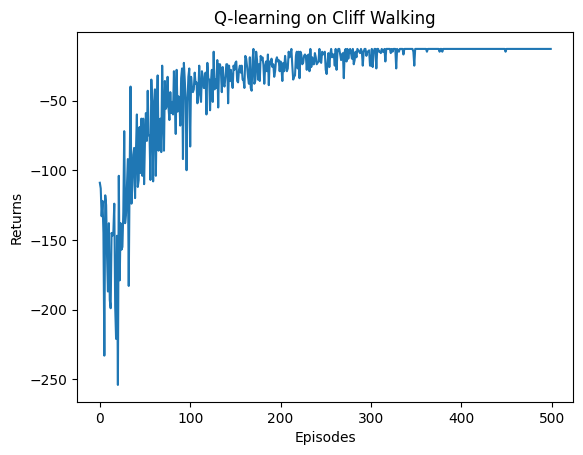

In [9]:
class QLearningDe:
    def __init__(self, ncol, nrow, epsilon, alpha, gamma, n_action=4):
        self.Q_table = np.zeros([nrow * ncol, n_action])
        self.n_action = n_action
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon


    def take_action(self, state, i=1):
        if np.random.rand() < self.epsilon * i:
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action
    
    def update(self, s0, a0, r, s1):
        td = r + self.gamma * self.Q_table[s1].max() - self.Q_table[s0, a0]
        self.Q_table[s0, a0] += self.alpha * td

np.random.seed(0)
ncol = 12
nrow = 4
env = CliffWalkingEnv(ncol, nrow)
epsilon = 0.1
alpha = 0.1
gamma = 0.9
agent = QLearningDe(ncol, nrow, epsilon, alpha, gamma)
num_episodes = 500  # 智能体在环境中运行的序列的数量

return_list = []  # 记录每一条序列的回报
for i in range(10):  # 显示10个进度条
    # tqdm的进度条功能
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):  # 每个进度条的序列数
            episode_return = 0
            state = env.reset()
            done = False
            rate = 1 / (num_episodes / 10 * i + i_episode + 1)
            while not done:
                action = agent.take_action(state, rate)
                next_state, reward, done = env.step(action)
                episode_return += reward  # 这里回报的计算不进行折扣因子衰减
                agent.update(state, action, reward, next_state)
                state = next_state
            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:  # 每10条序列打印一下这10条序列的平均回报
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Q-learning on {}'.format('Cliff Walking'))
plt.show()